Study the space-weather dataset features correlations, and come up with new target variable corresponding to the visibility of auroras

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pvlib import solarposition
import missingno as msno

In [134]:
df = pd.read_csv("data/raw/testdata1425full.csv")
# with pd.option_context('display.max_columns', None):
with pd.option_context('display.max_columns', None):
    display(df.head())

,raw_row_num,obs_id,activities_id,height_id,sky_id,observer_id,timestamp,address_country,address_state,location,see_aurora,sky_other,time_start,time_end,on_going,height_other,activities_other,colors_other,types_other,comment,image,st_y,st_x,colors,types,image_url,small_image_url,redact_row,pii_redacted,duration,mlat,mlon,mlt,longitude,latitude,date,hour,minutes,seconds,kp_3_hr_bucket,kp,bz_gsm,sigma_bz_gsm,ap,cloud_cover,visibility,is_day,moon_phase,moon_darkness
0,1,7372c36fe0c7,NaN,NaN,NaN,117.0,2014-10-01 08:21:34.818216+00:00,United Arab Emirates,Dubai,SRID=4326;POINT (55.154846755193745 25.0416718...,False,NaN,2014-10-01 08:15:00+00:00,2014-10-01 08:30:00+00:00,False,NaN,NaN,NaN,NaN,NaN,False,25.041672,55.154847,NaN,NaN,NaN,NaN,False,False,0.25,19.985358,128.137506,12.129542,55.154847,25.041672,2014-10-01,8,21,34,2,2.7,-1.466667,1.200000,10.625,0.0,-1,1,0.252,0.497
1,3,07c100d1ef09,NaN,NaN,clea,NaN,2014-10-02 13:47:29.552583+00:00,United States,NM,SRID=4326;POINT (-106.31864826448822 35.874131...,False,NaN,2014-10-02 13:45:00+00:00,2014-10-02 14:00:00+00:00,False,NaN,NaN,NaN,NaN,NaN,False,35.874132,-106.318648,NaN,NaN,NaN,NaN,False,False,0.25,44.155324,-39.100305,6.438991,-106.318648,35.874132,2014-10-02,13,47,29,4,1.7,-0.966667,1.566667,6.750,1.0,-1,0,0.286,0.429
2,6,90f6d683296b,quie,n,NaN,140.0,2014-10-08 18:09:23.114761+00:00,United States,NM,SRID=4326;POINT (-106.0875978020242 35.9777940...,True,NaN,2014-10-08 18:00:00+00:00,2014-10-08 18:15:00+00:00,False,NaN,NaN,NaN,NaN,NaN,False,35.977794,-106.087598,"red, whit",arcs,NaN,NaN,False,False,0.25,44.298471,-38.831876,10.782292,-106.087598,35.977794,2014-10-08,18,9,23,6,2.0,-5.200000,1.000000,7.625,99.0,-1,1,0.489,0.023
3,7,e6ffd03f4085,very,n45,NaN,141.0,2014-10-08 18:11:38.395952+00:00,United States,NM,SRID=4326;POINT (-106.33536318032095 35.858267...,True,NaN,2014-10-08 18:00:00+00:00,2014-10-08 18:15:00+00:00,False,NaN,NaN,NaN,NaN,NaN,False,35.858267,-106.335363,gree,"glow, patc",NaN,NaN,False,False,0.25,44.136071,-39.115849,10.763361,-106.335363,35.858267,2014-10-08,18,11,38,6,2.0,-5.200000,1.000000,7.625,99.0,-1,1,0.489,0.023
4,8,a67afd419547,acti,over,NaN,141.0,2014-10-08 18:15:51.473713+00:00,United States,NM,SRID=4326;POINT (-106.3362134605038 35.8694066...,True,NaN,2014-10-08 18:00:00+00:00,2014-10-08 18:15:00+00:00,True,NaN,NaN,NaN,NaN,NaN,False,35.869407,-106.336213,"whit, gree, pink","arcs, glow",NaN,NaN,False,False,0.25,44.147181,-39.118361,10.763193,-106.336213,35.869407,2014-10-08,18,15,51,6,2.0,-5.200000,1.000000,7.625,99.0,-1,1,0.489,0.023


In [135]:
df.describe()

,raw_row_num,observer_id,st_y,st_x,image_url,small_image_url,duration,mlat,mlon,mlt,...,kp_3_hr_bucket,kp,bz_gsm,sigma_bz_gsm,ap,cloud_cover,visibility,is_day,moon_phase,moon_darkness
count,22280.000000,7792.000000,22280.000000,22280.000000,0.0,0.0,22280.000000,22264.000000,22264.000000,22264.000000,...,22280.000000,22280.000000,22202.000000,22205.000000,22280.000000,22280.000000,22280.0,22280.000000,22280.000000,22280.000000
mean,15107.635637,7280.147459,46.557351,-53.404493,NaN,NaN,0.926010,49.463710,8.879975,18.420036,...,3.595691,4.371405,-3.676730,3.189965,62.071768,42.134381,-1.0,0.303142,0.381787,0.567260
std,8573.920032,4271.916980,17.225247,65.551004,NaN,NaN,1.300723,18.417134,64.892212,6.581041,...,2.607533,2.580240,7.235688,3.347755,83.987867,41.310615,0.0,0.459626,0.287557,0.254317
min,1.000000,114.000000,-90.000000,-165.995469,NaN,NaN,0.000000,-81.236834,-178.730649,0.000437,...,0.000000,0.000000,-29.933333,0.000000,0.000000,0.000000,-1.0,0.000000,0.000000,0.000000
25%,7847.250000,4095.000000,42.841596,-105.024840,NaN,NaN,0.250000,48.026064,-45.710332,19.066910,...,1.000000,2.300000,-6.766667,1.133333,10.250000,1.000000,-1.0,0.000000,0.125000,0.382000
50%,15077.500000,7747.000000,48.842860,-79.908635,NaN,NaN,0.250000,52.273023,-7.562771,20.894562,...,3.000000,4.000000,-1.733333,1.900000,24.750000,27.000000,-1.0,0.000000,0.261000,0.618000
75%,22519.500000,11025.250000,53.533093,-0.603101,NaN,NaN,1.000000,56.812396,76.250964,22.076297,...,6.000000,6.300000,0.900000,3.433333,70.500000,92.000000,-1.0,1.000000,0.625000,0.777000
max,30020.000000,16929.000000,78.900911,177.505901,NaN,NaN,11.750000,83.213953,179.841986,23.999655,...,7.000000,9.000000,26.900000,16.066667,270.750000,100.000000,-1.0,1.000000,1.000000,1.000000


In [136]:
with pd.option_context('display.max_columns', None):
    df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22280 entries, 0 to 22279
Data columns (total 49 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   raw_row_num       22280 non-null  int64  
 1   obs_id            22280 non-null  str    
 2   activities_id     14225 non-null  str    
 3   height_id         14329 non-null  str    
 4   sky_id            4229 non-null   str    
 5   observer_id       7792 non-null   float64
 6   timestamp         22280 non-null  str    
 7   address_country   22123 non-null  str    
 8   address_state     21406 non-null  str    
 9   location          22280 non-null  str    
 10  see_aurora        22280 non-null  bool   
 11  sky_other         293 non-null    str    
 12  time_start        22280 non-null  str    
 13  time_end          22280 non-null  str    
 14  on_going          22280 non-null  bool   
 15  height_other      1289 non-null   str    
 16  activities_other  758 non-null    str    
 17  colo

In [137]:
df['sky_id'].unique()

<ArrowStringArray>
[nan, 'clea']
Length: 2, dtype: str

In [153]:
df.loc[df["sky_id"]=="clea", "see_aurora"].value_counts()

see_aurora
False    4229
Name: count, dtype: int64

In [138]:
df['is_day'].unique()

array([1, 0])

In [139]:
# Create binary flag: 1 if clear, 0 if cloudy/obstructed/missing
df['is_clear'] = (df['sky_id'] == 'clea').astype(int)

In [140]:
df.loc[df["cloud_cover"]>80, "see_aurora"].value_counts()

see_aurora
True     5091
False    1672
Name: count, dtype: int64

<Axes: >

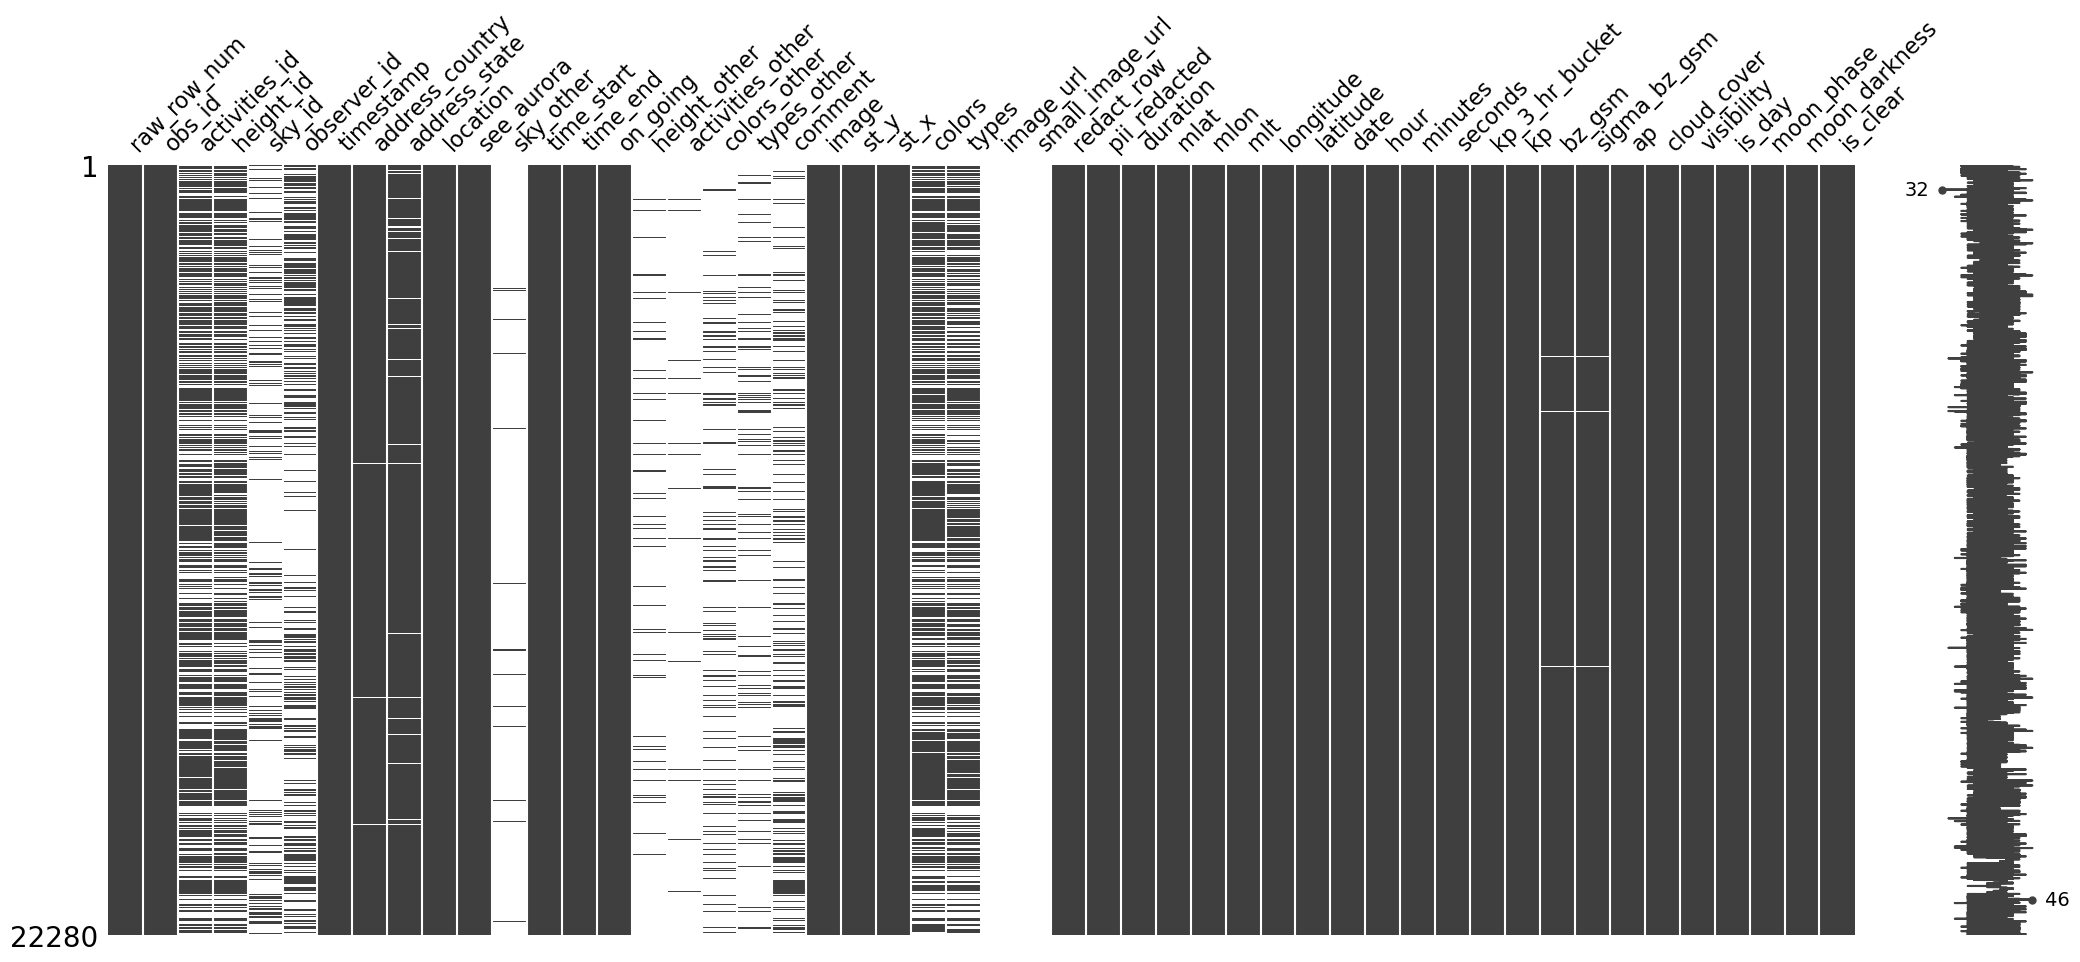

In [141]:
msno.matrix(df)

<Axes: >

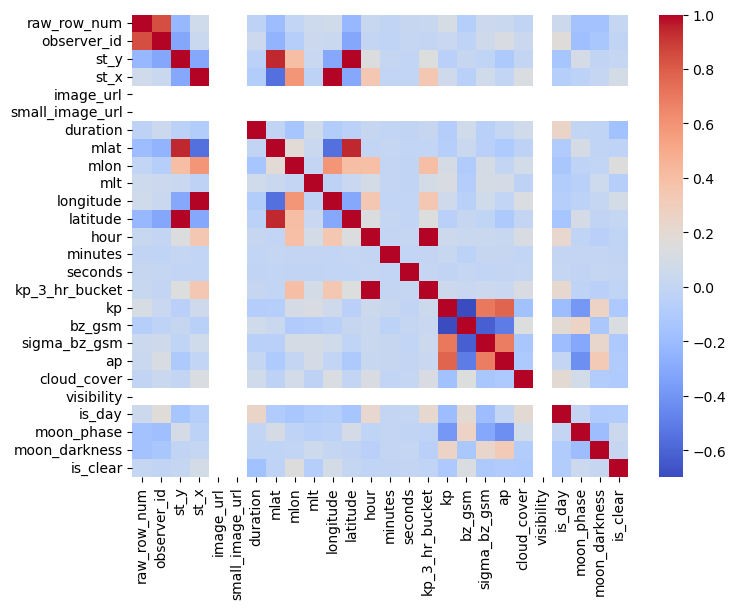

In [142]:
## Filter out all non-numeric columns
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False) # Keep annot=False for many columns

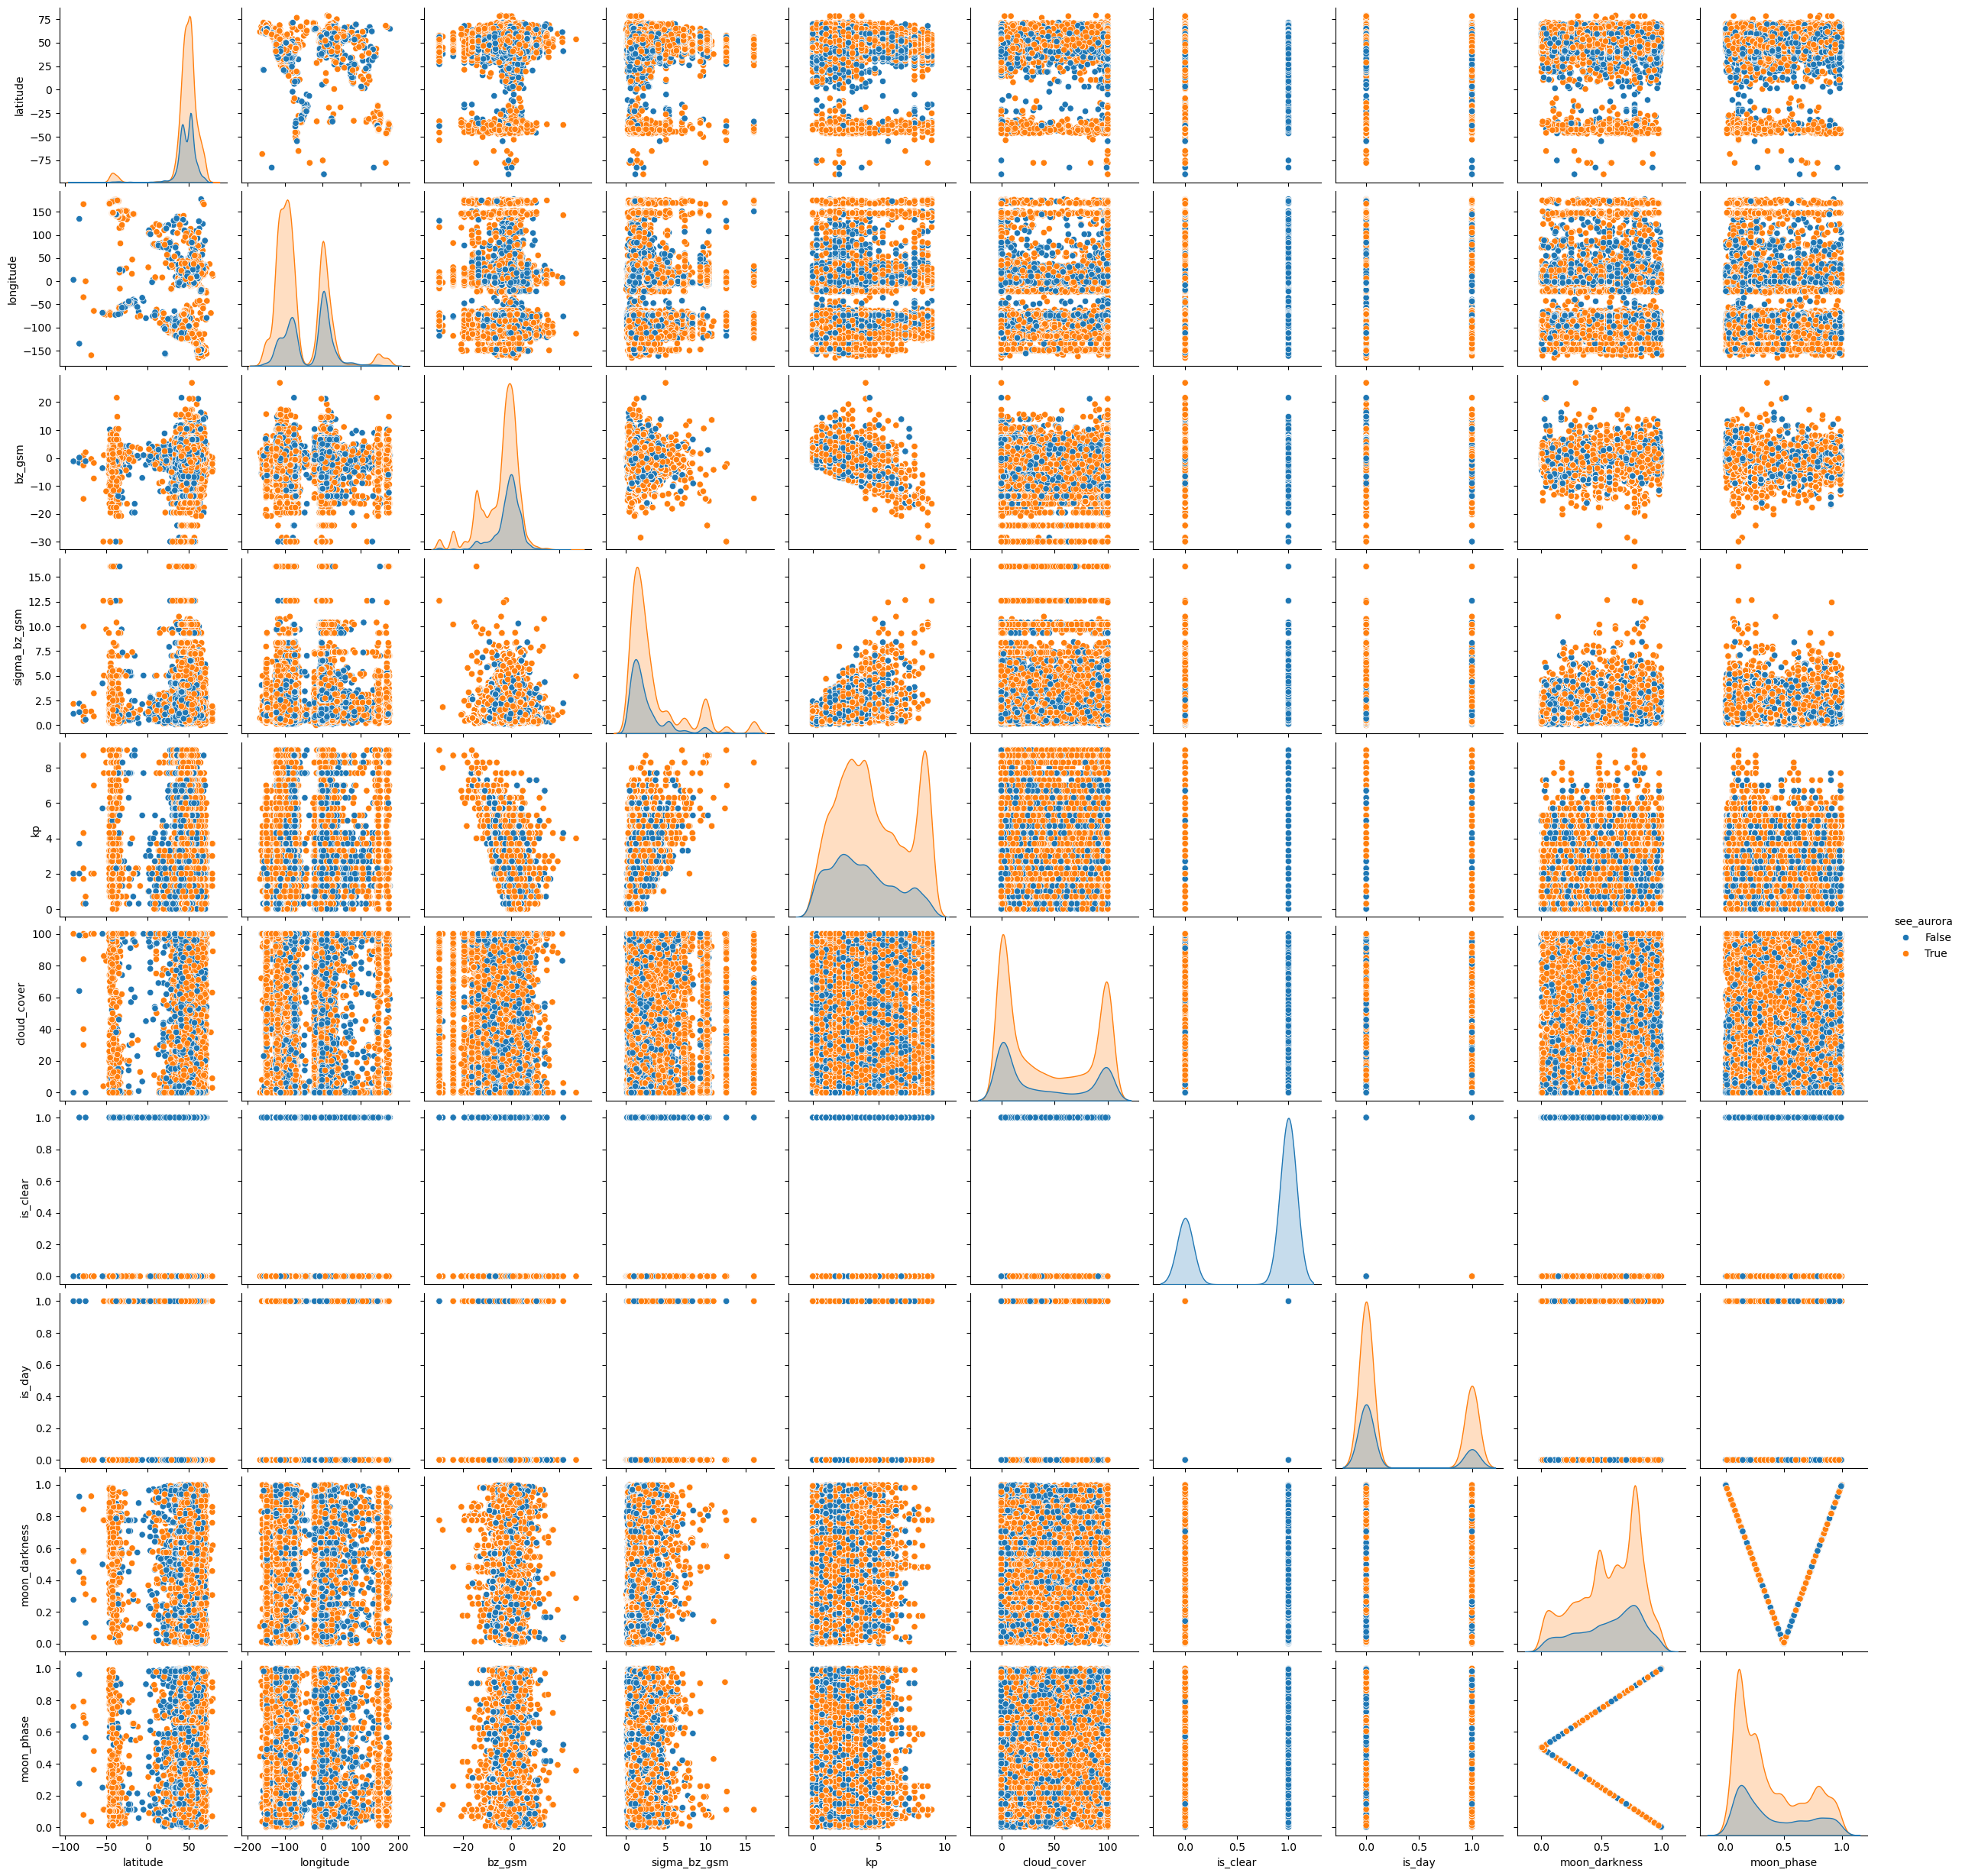

In [143]:
### verify the corelations between the features
cols = ['latitude', 'longitude', 'bz_gsm', 'sigma_bz_gsm', 'kp', 'cloud_cover', 'is_clear', 'is_day','moon_darkness', 'moon_phase']
sns.pairplot(data=df, x_vars=cols, y_vars=cols, hue="see_aurora")

There seems a strong correlation between `moon_darkness` and `moon_phase`. To suppress multicollinearity, we replace the two features by one `lunar_sky_glare` which assess the skylight pollution: lunar_sky_glare = moon_phase * (1 - moon_darkness)

In [ ]:
df['lunar_sky_glare'] = df['moon_phase'] * (1.0 - df['moon_darkness'])
df_skimmed = df.dropna(subset=['latitude', 'longitude', 'bz_gsm', 'sigma_bz_gsm', 'kp', 'cloud_cover', 'is_clear', 'is_day', 'lunar_sky_glare', 'see_aurora'])
columns_to_keep = ['latitude', 'longitude', 'bz_gsm', 'sigma_bz_gsm', 'kp', 'cloud_cover', 'is_clear', 'is_day', 'lunar_sky_glare', 'see_aurora']
df_skimmed = df_skimmed[columns_to_keep]
## convert 'see_aurora' to 1 and 0
df_skimmed['see_aurora'] = df_skimmed['see_aurora'].astype(int)
df_skimmed.head()

,latitude,longitude,bz_gsm,sigma_bz_gsm,kp,cloud_cover,is_clear,is_day,lunar_sky_glare,see_aurora
0,25.041672,55.154847,-1.466667,1.200000,2.7,0.0,0,1,0.126756,0
1,35.874132,-106.318648,-0.966667,1.566667,1.7,1.0,1,0,0.163306,0
2,35.977794,-106.087598,-5.200000,1.000000,2.0,99.0,0,1,0.477753,1
3,35.858267,-106.335363,-5.200000,1.000000,2.0,99.0,0,1,0.477753,1
4,35.869407,-106.336213,-5.200000,1.000000,2.0,99.0,0,1,0.477753,1


In [145]:
df_skimmed.describe()

,latitude,longitude,bz_gsm,sigma_bz_gsm,kp,cloud_cover,is_clear,is_day,lunar_sky_glare,see_aurora
count,22202.000000,22202.000000,22202.000000,22202.000000,22202.000000,22202.000000,22202.000000,22202.000000,22202.000000,22202.000000
mean,46.551302,-53.290591,-3.676730,3.190210,4.370494,42.078371,0.190298,0.302000,0.179793,0.734123
std,17.251487,65.591899,7.235688,3.347905,2.579743,41.300309,0.392545,0.459136,0.161564,0.441809
min,-90.000000,-165.995469,-29.933333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.837155,-105.000233,-6.766667,1.133333,2.300000,1.000000,0.000000,0.000000,0.025662,0.000000
50%,48.855145,-79.841063,-1.733333,1.900000,4.000000,27.000000,0.000000,0.000000,0.133903,1.000000
75%,53.535656,-0.577930,0.900000,3.433333,6.300000,92.000000,0.000000,1.000000,0.313632,1.000000
max,78.900911,177.505901,26.900000,16.066667,9.000000,100.000000,1.000000,1.000000,0.500485,1.000000


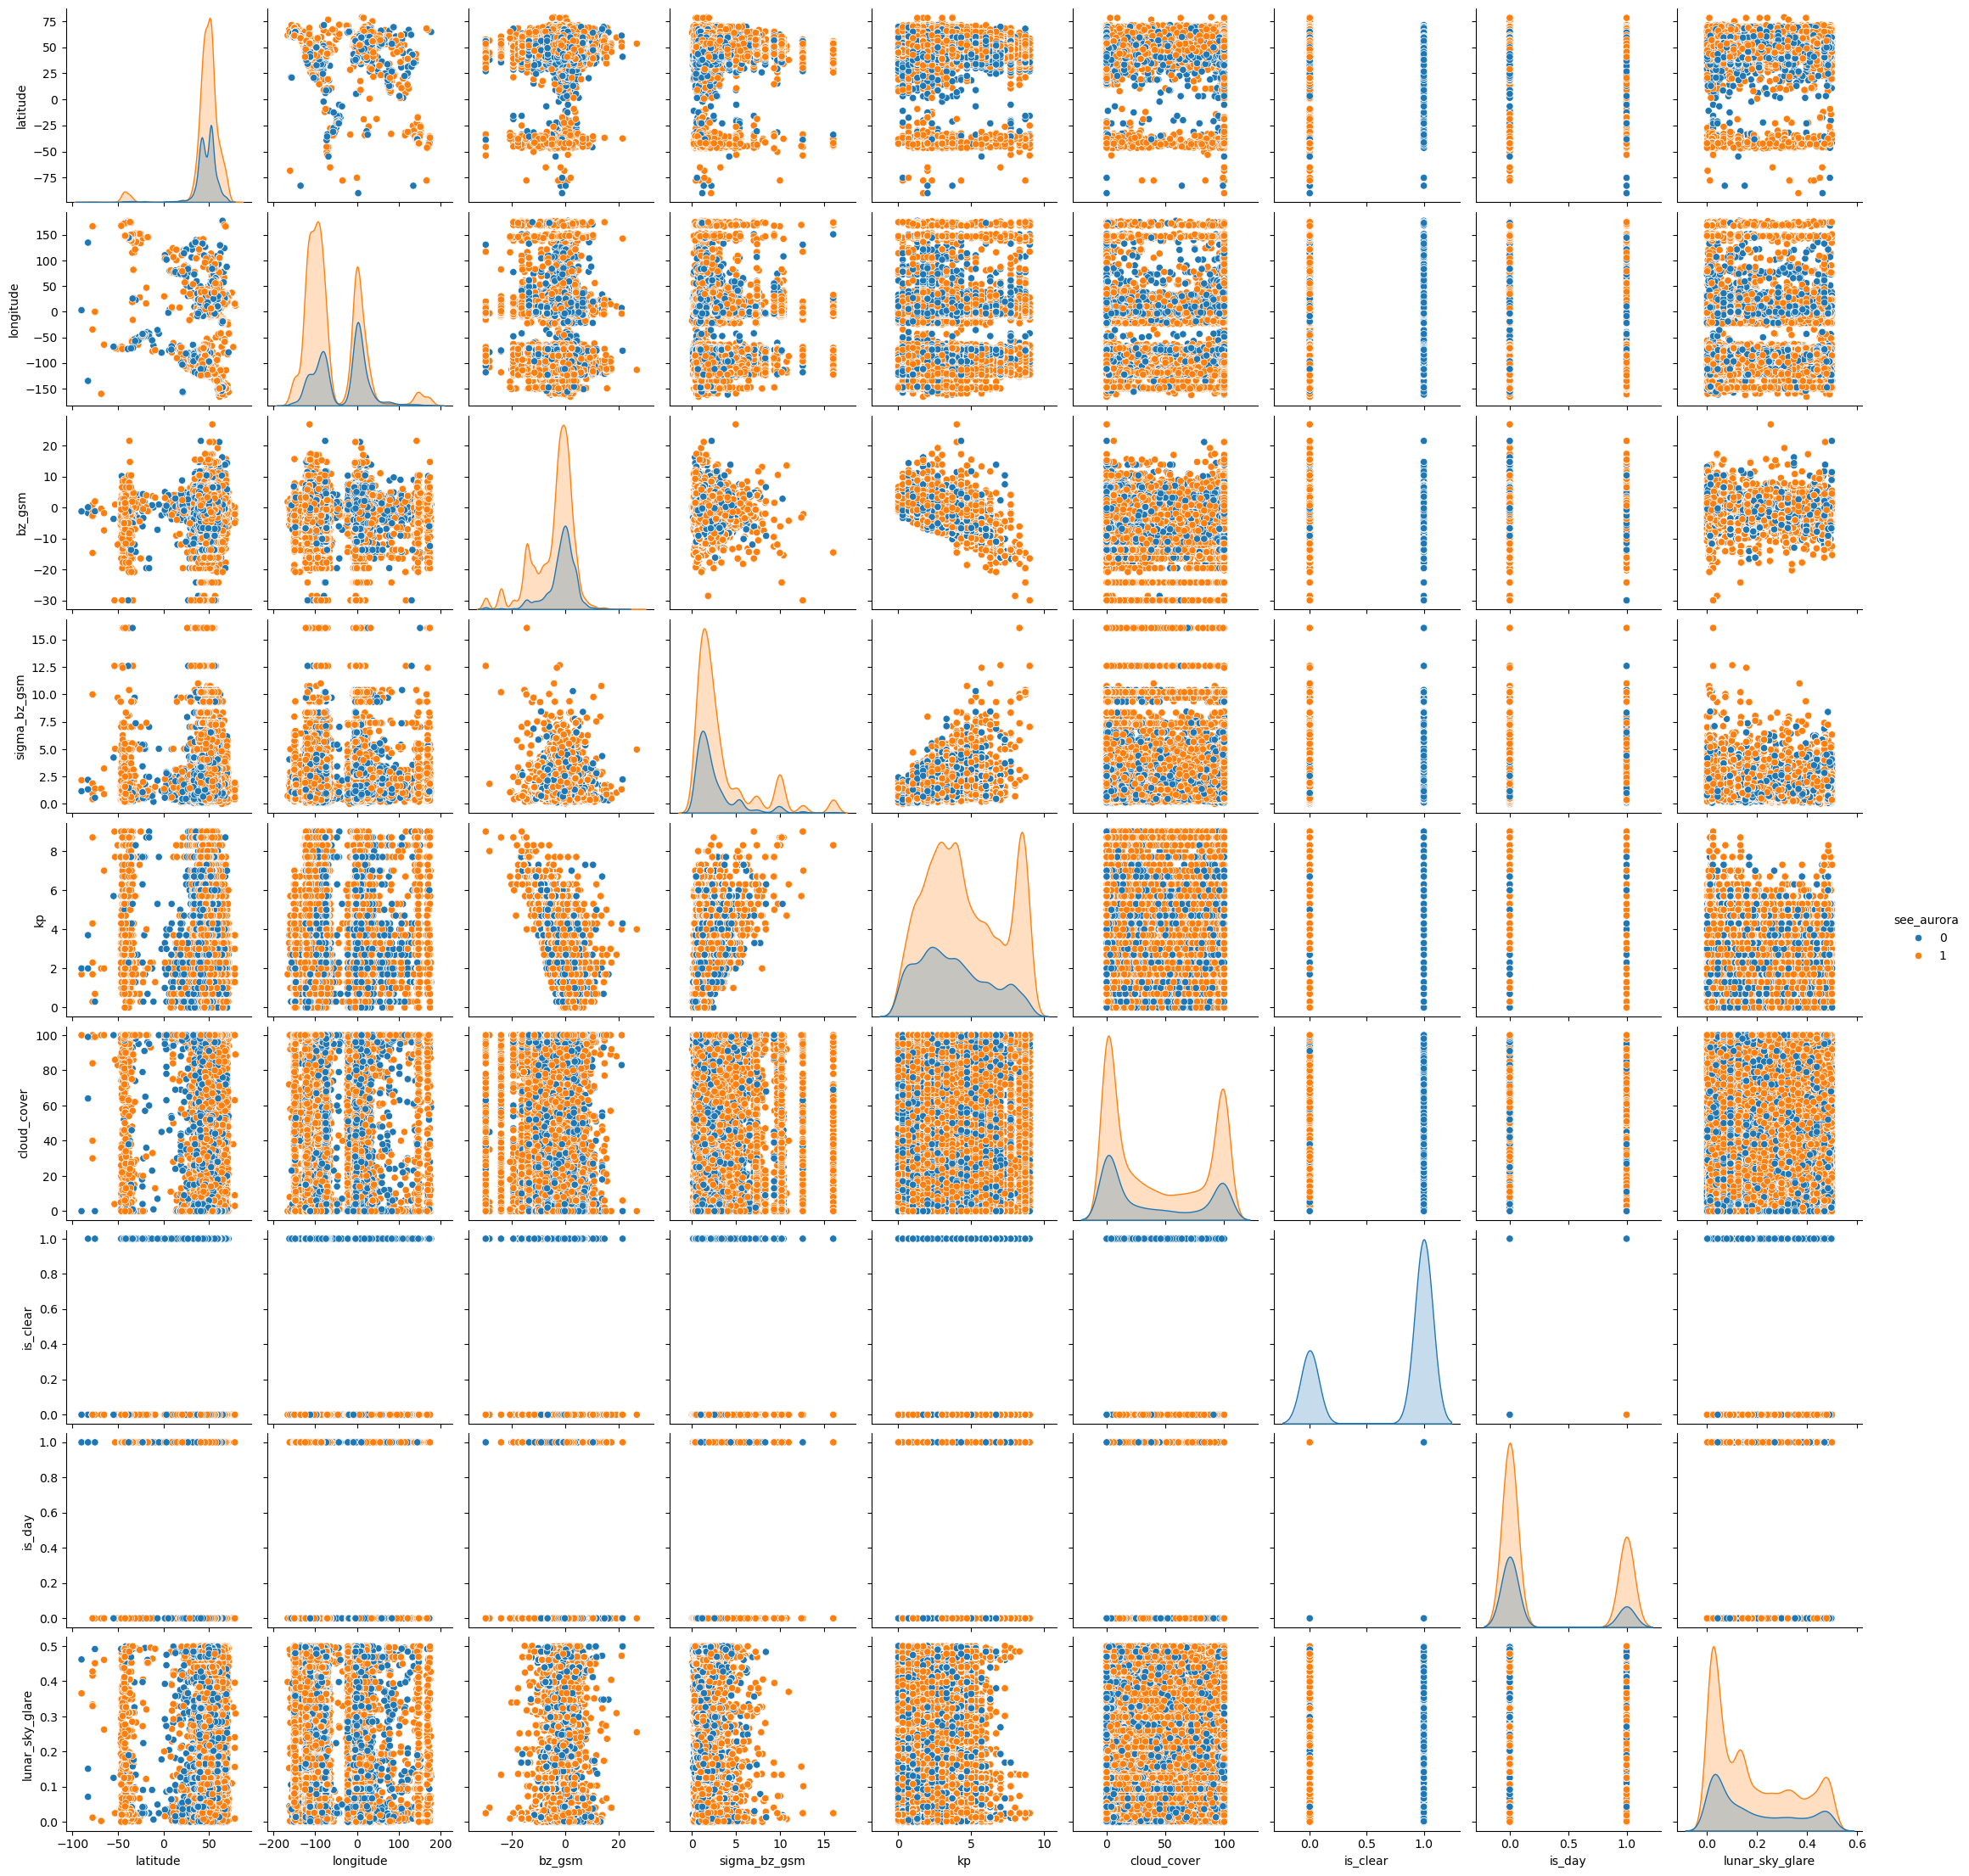

In [146]:
features = ['latitude', 'longitude', 'bz_gsm', 'sigma_bz_gsm', 'kp', 'cloud_cover', 'is_clear', 'is_day', 'lunar_sky_glare']
sns.pairplot(data=df_skimmed, x_vars=features, y_vars=features, hue="see_aurora")

In [147]:
aurora_sighting_clouds_lt20 = (df_skimmed[(df_skimmed['cloud_cover'] < 20)]['see_aurora'] == 1).mean()*100
aurora_sighting_clouds_lt50 = (df_skimmed[(df_skimmed['cloud_cover'] < 50)]['see_aurora'] == 1).mean()*100
aurora_sighting_clouds_gt80 = (df_skimmed[(df_skimmed['cloud_cover'] > 80)]['see_aurora'] == 1).mean()*100
print(f"{aurora_sighting_clouds_lt20:.2f}% of aurora seen when cloud cover < 20%")
print(f"{aurora_sighting_clouds_lt50:.2f}% of aurora seen when cloud cover < 50%")
print(f"{aurora_sighting_clouds_gt80:.2f}% of aurora seen when cloud cover > 80%")        
    

71.29% of aurora seen when cloud cover < 20%
72.02% of aurora seen when cloud cover < 50%
75.16% of aurora seen when cloud cover > 80%


In [155]:
clouds_and_is_clear_lt20 = (df_skimmed[(df_skimmed['is_clear']==1)]['cloud_cover'] < 20).mean()*100
clouds_and_is_clear_lt50 = (df_skimmed[(df_skimmed['is_clear']==1)]['cloud_cover'] < 50).mean()*100
clouds_and_is_clear_gt80 = (df_skimmed[(df_skimmed['is_clear']==1)]['cloud_cover'] > 80).mean()*100
print(f"{clouds_and_is_clear_lt20:.2f}% of cloud cover when sky is clear")
print(f"{clouds_and_is_clear_lt50:.2f}% of cloud cover when sky is clear")
print(f"{clouds_and_is_clear_gt80:.2f}% of cloud cover when sky is clear")

55.24% of cloud cover when sky is clear
68.36% of cloud cover when sky is clear
22.30% of cloud cover when sky is clear


In [177]:
df_skimmed['see_aurora'].value_counts(normalize=True) * 100

see_aurora
1    73.412305
0    26.587695
Name: proportion, dtype: float64

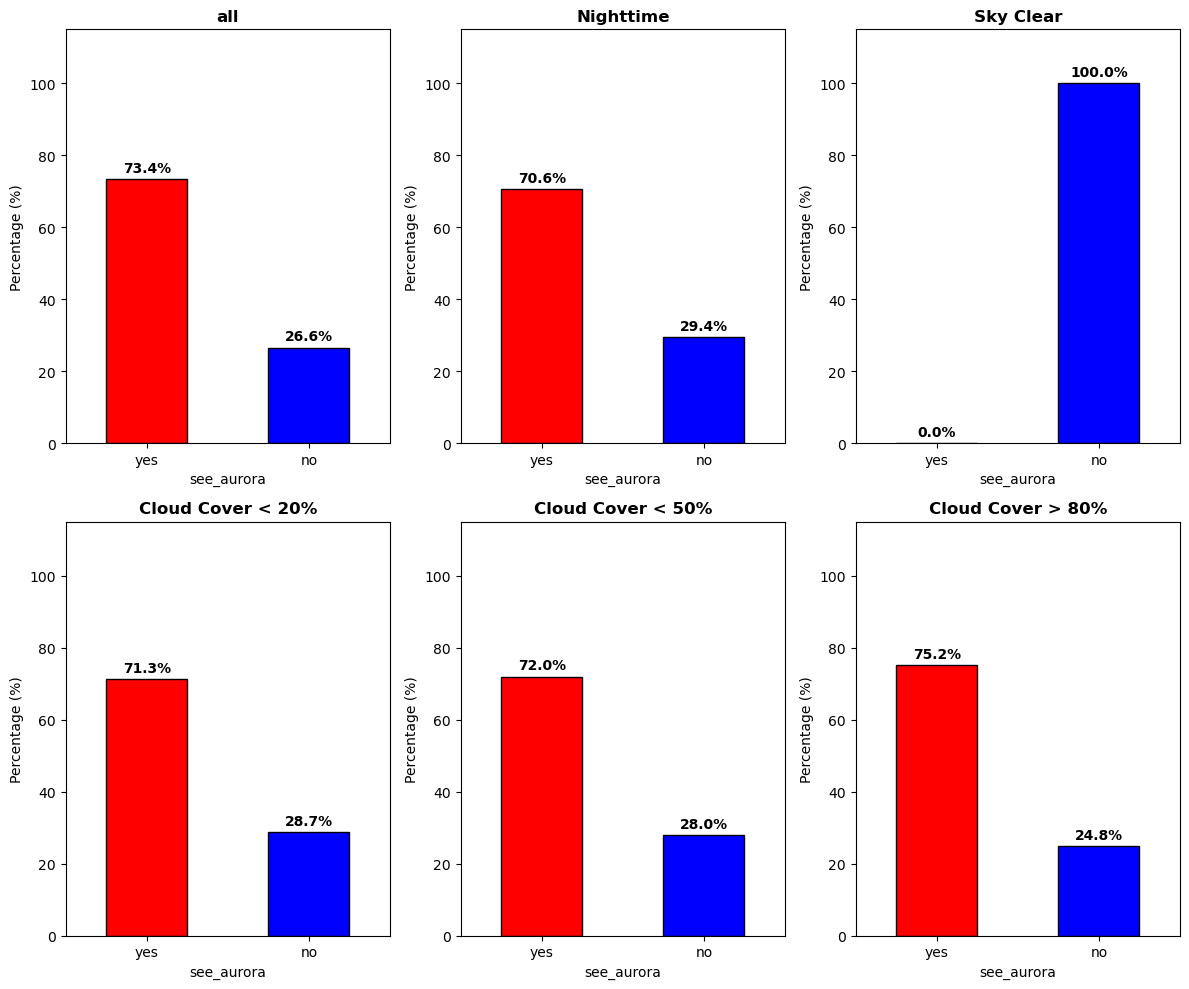

In [197]:
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

cuts = {
    "all": df_skimmed['see_aurora'] != 2,
    "Nighttime": df_skimmed['is_day'] == 0,
    "Sky Clear": df_skimmed['is_clear'] == 1,
    "Cloud Cover < 20%": df_skimmed['cloud_cover'] < 20,
    "Cloud Cover < 50%": df_skimmed['cloud_cover'] < 50,
    "Cloud Cover > 80%": df_skimmed['cloud_cover'] > 80
}

for index, (key, value) in enumerate(cuts.items()):
    (df_skimmed[value]['see_aurora'].value_counts(normalize=True).reindex([1, 0]) * 100).plot(
    kind='bar',
    color=["red", 'blue'],
    edgecolor='black',
    ax=axes[index])
    axes[index].bar_label(axes[index].containers[0], fmt='%.1f%%', fontweight='bold', padding=3)
    axes[index].set_title(key, fontweight='bold', fontsize=12)
    axes[index].set_ylabel('Percentage (%)')
    axes[index].set_xticklabels(['yes', 'no'], rotation=0) 
    axes[index].set_ylim(0, 115)
    
plt.tight_layout()
plt.show()   